# Perbandingan Model Klasifikasi Fashion-MNIST

Notebook ini mendokumentasikan mini project Deep Learning untuk mengklasifikasikan citra pakaian Fashion-MNIST. Eksperimen membandingkan baseline linear, MLP, dan CNN pada data serta metrik evaluasi yang sama.

## Tujuan dan Alur Eksperimen

Tujuan eksperimen adalah memahami data citra, melakukan preprocessing yang benar, melatih beberapa model, memilih model terbaik, dan menganalisis kesalahan prediksi. Alur yang digunakan: load data -> EDA -> preprocessing -> training baseline/MLP/CNN -> evaluasi -> analisis error -> kesimpulan.

## 1. Import Library

Kode final tetap berada di `src/proyek.py`. Notebook ini mengimpor fungsi dari source tersebut agar eksperimen, laporan, dan submission tetap sinkron.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

from proyek import (
    NAMA_KELAS,
    CNN_EPOCHS,
    MLP_EPOCHS,
    contoh_salah,
    jalankan_eksperimen,
    kelas_tertukar,
    muat_data,
    prediksi_label,
    siapkan_data,
)


## 2. Load Dataset

Fashion-MNIST berisi citra grayscale 28x28 dari 10 kategori pakaian. Dataset ini lebih menantang daripada digit 8x8 karena beberapa kelas memiliki bentuk visual yang mirip, misalnya T-shirt/top dengan Shirt, atau Pullover dengan Coat.

In [2]:
data = muat_data()
print("Train full:", data["X_train"].shape, data["y_train"].shape)
print("Test full :", data["X_test"].shape, data["y_test"].shape)
print("Kelas     :", NAMA_KELAS)


Train full: (60000, 28, 28) (60000,)
Test full : (10000, 28, 28) (10000,)
Kelas     : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Validasi Data

Validasi memastikan bentuk citra, jumlah label, dan rentang piksel sesuai sebelum model dilatih. Kesalahan pada tahap ini dapat membuat hasil evaluasi tidak dapat dipercaya.

In [3]:
assert data["X_train"].ndim == 3
assert data["X_train"].shape[1:] == (28, 28)
assert set(np.unique(data["y_train"])) == set(range(10))
assert data["X_train"].min() >= 0 and data["X_train"].max() <= 255
print("Validasi data berhasil.")


Validasi data berhasil.


## 4. Exploratory Data Analysis

EDA dilakukan untuk melihat distribusi kelas, contoh visual setiap kelas, dan karakteristik piksel. Bagian ini membantu menjelaskan mengapa beberapa kelas lebih sulit dibedakan.

,Kelas,Jumlah
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


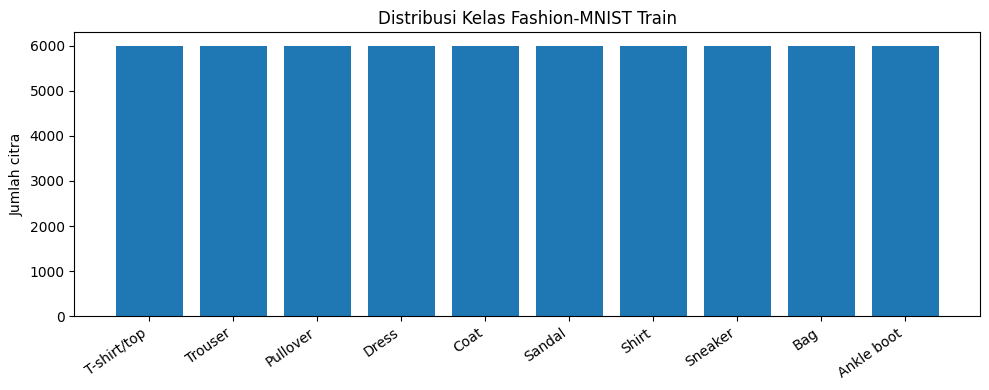

In [4]:
kelas, jumlah = np.unique(data["y_train"], return_counts=True)
distribusi = pd.DataFrame({"Kelas": [NAMA_KELAS[i] for i in kelas], "Jumlah": jumlah})
display(distribusi)

plt.figure(figsize=(10, 4))
plt.bar(distribusi["Kelas"], distribusi["Jumlah"])
plt.xticks(rotation=35, ha="right")
plt.title("Distribusi Kelas Fashion-MNIST Train")
plt.ylabel("Jumlah citra")
plt.tight_layout()
plt.show()


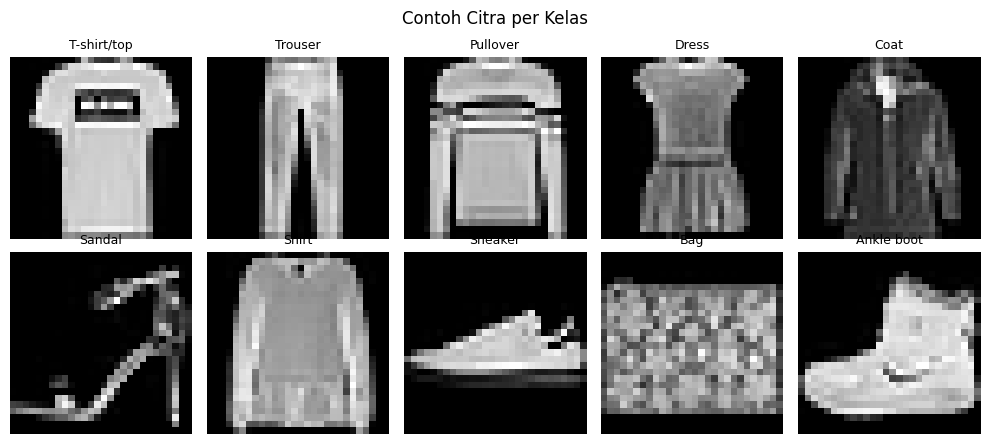

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for label, ax in enumerate(axes.ravel()):
    idx = np.where(data["y_train"] == label)[0][0]
    ax.imshow(data["X_train"][idx], cmap="gray")
    ax.set_title(NAMA_KELAS[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Contoh Citra per Kelas")
plt.tight_layout()
plt.show()


Pixel min/max sebelum normalisasi: 0 255


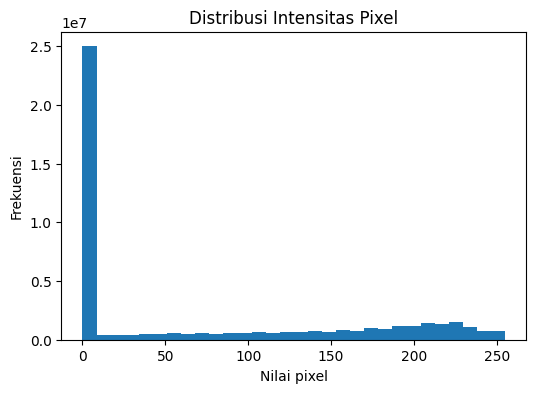

In [6]:
print("Pixel min/max sebelum normalisasi:", data["X_train"].min(), data["X_train"].max())
plt.figure(figsize=(6, 4))
plt.hist(data["X_train"].ravel(), bins=30)
plt.title("Distribusi Intensitas Pixel")
plt.xlabel("Nilai pixel")
plt.ylabel("Frekuensi")
plt.show()


## 5. Preprocessing

Preprocessing dilakukan di `siapkan_data()` pada `src/proyek.py`. Nilai piksel dinormalisasi ke rentang 0 sampai 1, lalu citra dibuat menjadi bentuk `(28, 28, 1)` agar cocok untuk CNN. Baseline dan MLP memakai versi flattened yang dibuat di dalam fungsi training/evaluasi.

In [7]:
X_train, X_test, y_train, y_test = siapkan_data(data)
print("Train subset:", X_train.shape, y_train.shape)
print("Test subset :", X_test.shape, y_test.shape)
print("Pixel min/max setelah normalisasi:", float(X_train.min()), float(X_train.max()))


Train subset: (12000, 28, 28, 1) (12000,)
Test subset : (3000, 28, 28, 1) (3000,)
Pixel min/max setelah normalisasi: 0.0 1.0


## 6. Model yang Dibandingkan

Tiga model dibandingkan secara bertahap. Baseline linear memakai SGD Logistic untuk melihat performa fitur piksel mentah. MLP menambahkan hidden layer non-linear, sedangkan CNN memanfaatkan struktur spasial citra melalui konvolusi dan pooling.

In [8]:
print("Baseline : SGD Logistic pada pixel flattened")
print(f"MLP      : Dense 128 -> Dropout -> Dense 64 -> Softmax, epoch={MLP_EPOCHS}")
print(f"CNN      : Conv32 -> Pool -> Conv64 -> Pool -> Dense128 -> Softmax, epoch={CNN_EPOCHS}")


Baseline : SGD Logistic pada pixel flattened
MLP      : Dense 128 -> Dropout -> Dense 64 -> Softmax, epoch=4
CNN      : Conv32 -> Pool -> Conv64 -> Pool -> Dense128 -> Softmax, epoch=8


## 7. Training dan Evaluasi

Seluruh eksperimen dijalankan oleh `jalankan_eksperimen()` dari source final. Fungsi ini mengembalikan data, model, dan metrik agar notebook tidak membuat pipeline kedua.

In [9]:
data, data_split, models, hasil = jalankan_eksperimen()
X_train, X_test, y_train, y_test = data_split
hasil_df = pd.DataFrame([
    {
        "Model": nama,
        "Accuracy": metrik["akurasi"],
        "Precision Macro": metrik["precision_macro"],
        "Recall Macro": metrik["recall_macro"],
        "F1 Macro": metrik["f1_macro"],
        "Waktu Latih (s)": metrik["waktu_latih"],
    }
    for nama, metrik in hasil.items()
]).sort_values("F1 Macro", ascending=False)
display(hasil_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision Macro": "{:.4f}",
    "Recall Macro": "{:.4f}",
    "F1 Macro": "{:.4f}",
    "Waktu Latih (s)": "{:.2f}",
}))


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Waktu Latih (s)
2,CNN,0.8737,0.8729,0.8737,0.8727,10.95
1,MLP,0.8380,0.8419,0.8380,0.8352,2.08
0,Baseline SGD Logistic,0.8233,0.8291,0.8233,0.8210,8.90


## 8. Kurva Training Neural Network

Kurva training membantu melihat apakah model masih belajar atau mulai overfit. Baseline linear tidak memiliki kurva loss Keras, sehingga bagian ini hanya menampilkan MLP dan CNN.

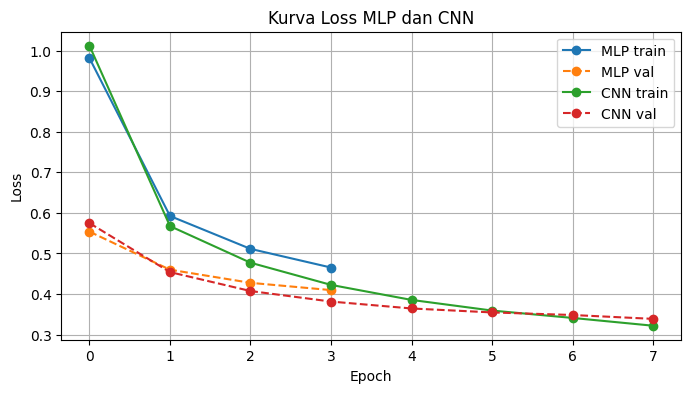

In [10]:
plt.figure(figsize=(8, 4))
for nama in ["MLP", "CNN"]:
    riwayat = getattr(models[nama], "riwayat", {})
    if "loss" in riwayat:
        plt.plot(riwayat["loss"], marker="o", label=f"{nama} train")
    if "val_loss" in riwayat:
        plt.plot(riwayat["val_loss"], marker="o", linestyle="--", label=f"{nama} val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Kurva Loss MLP dan CNN")
plt.legend()
plt.grid(True)
plt.show()


## 9. Classification Report

Classification report menampilkan precision, recall, dan F1 untuk setiap kelas. Ini penting karena accuracy saja tidak menjelaskan kelas mana yang paling sulit dikenali.

In [11]:
nama_terbaik = hasil_df.iloc[0]["Model"]
model_terbaik = models[nama_terbaik]
pred_terbaik = prediksi_label(model_terbaik, X_test)
print("Model terbaik:", nama_terbaik)
print(classification_report(y_test, pred_terbaik, target_names=NAMA_KELAS, digits=4, zero_division=0))


Model terbaik: CNN
              precision    recall  f1-score   support

 T-shirt/top     0.8170    0.8333    0.8251       300
     Trouser     0.9798    0.9700    0.9749       300
    Pullover     0.8351    0.7933    0.8137       300
       Dress     0.8536    0.9133    0.8824       300
        Coat     0.7652    0.8367    0.7994       300
      Sandal     0.9664    0.9600    0.9632       300
       Shirt     0.6880    0.6100    0.6466       300
     Sneaker     0.9331    0.9300    0.9316       300
         Bag     0.9589    0.9333    0.9459       300
  Ankle boot     0.9318    0.9567    0.9441       300

    accuracy                         0.8737      3000
   macro avg     0.8729    0.8737    0.8727      3000
weighted avg     0.8729    0.8737    0.8727      3000



## 10. Confusion Matrix

Confusion matrix memperlihatkan kelas yang benar dan kelas prediksi. Nilai di luar diagonal utama menunjukkan jenis kesalahan model.

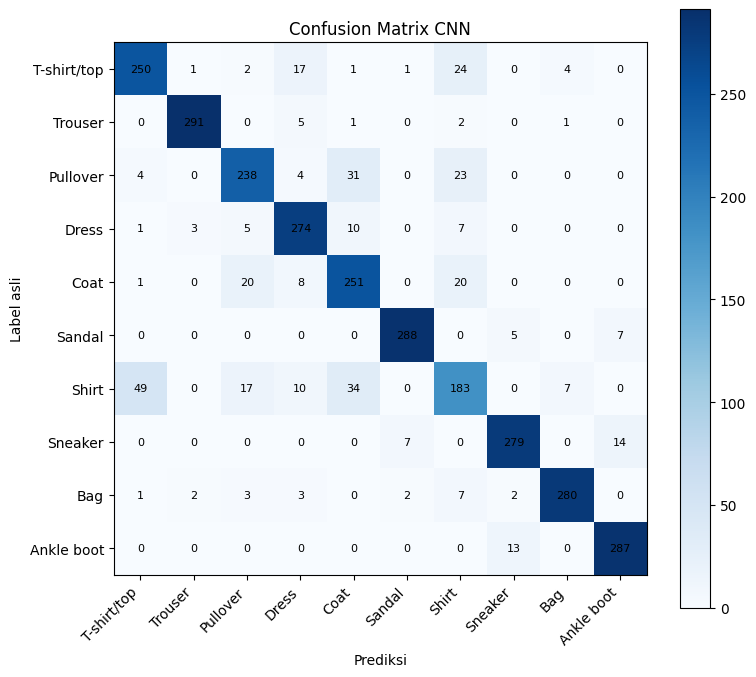

In [12]:
cm = np.array(hasil[nama_terbaik]["confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), NAMA_KELAS, rotation=45, ha="right")
ax.set_yticks(range(10), NAMA_KELAS)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Label asli")
ax.set_title(f"Confusion Matrix {nama_terbaik}")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 11. Kelas yang Sering Tertukar

Pasangan kelas berikut menunjukkan kesalahan terbesar. Pada Fashion-MNIST, kesalahan yang wajar biasanya terjadi antar pakaian yang bentuknya mirip.

In [13]:
tertukar = kelas_tertukar(hasil[nama_terbaik]["confusion_matrix"], jumlah=8)
pd.DataFrame(tertukar, columns=["Jumlah", "Label asli", "Prediksi"])


,Jumlah,Label asli,Prediksi
0,49,Shirt,T-shirt/top
1,34,Shirt,Coat
2,31,Pullover,Coat
3,24,T-shirt/top,Shirt
4,23,Pullover,Shirt
5,20,Coat,Shirt
6,20,Coat,Pullover
7,17,T-shirt/top,Dress


## 12. Analisis Prediksi Salah

Contoh prediksi salah ditampilkan agar kesalahan model bisa dianalisis secara visual, bukan hanya dari angka.

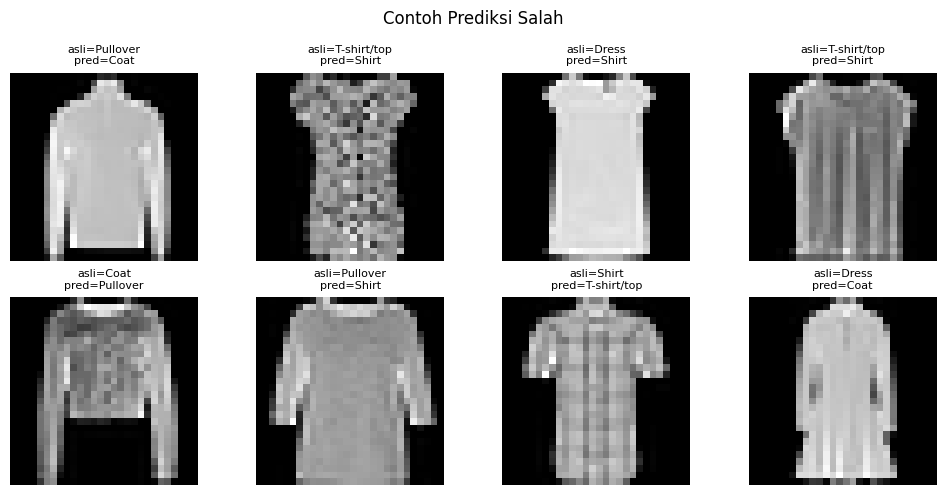

[{'index': 3,
  'label_asli': 2,
  'nama_asli': 'Pullover',
  'prediksi': 4,
  'nama_prediksi': 'Coat'},
 {'index': 16,
  'label_asli': 0,
  'nama_asli': 'T-shirt/top',
  'prediksi': 6,
  'nama_prediksi': 'Shirt'},
 {'index': 19,
  'label_asli': 3,
  'nama_asli': 'Dress',
  'prediksi': 6,
  'nama_prediksi': 'Shirt'},
 {'index': 45,
  'label_asli': 0,
  'nama_asli': 'T-shirt/top',
  'prediksi': 6,
  'nama_prediksi': 'Shirt'},
 {'index': 58,
  'label_asli': 4,
  'nama_asli': 'Coat',
  'prediksi': 2,
  'nama_prediksi': 'Pullover'},
 {'index': 69,
  'label_asli': 2,
  'nama_asli': 'Pullover',
  'prediksi': 6,
  'nama_prediksi': 'Shirt'},
 {'index': 72,
  'label_asli': 6,
  'nama_asli': 'Shirt',
  'prediksi': 0,
  'nama_prediksi': 'T-shirt/top'},
 {'index': 75,
  'label_asli': 3,
  'nama_asli': 'Dress',
  'prediksi': 4,
  'nama_prediksi': 'Coat'}]

In [14]:
salah = contoh_salah(model_terbaik, X_test, y_test, jumlah=8)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, item in zip(axes.ravel(), salah):
    idx = item["index"]
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    ax.set_title(f"asli={item['nama_asli']}\npred={item['nama_prediksi']}", fontsize=8)
    ax.axis("off")
plt.suptitle("Contoh Prediksi Salah")
plt.tight_layout()
plt.show()
salah


## 13. Prediksi Beberapa Citra Baru dari Data Uji

Bagian ini memperlihatkan prediksi model terbaik pada beberapa citra data uji. Tujuannya untuk memastikan model dapat dipakai pada sampel yang tidak dilatih.

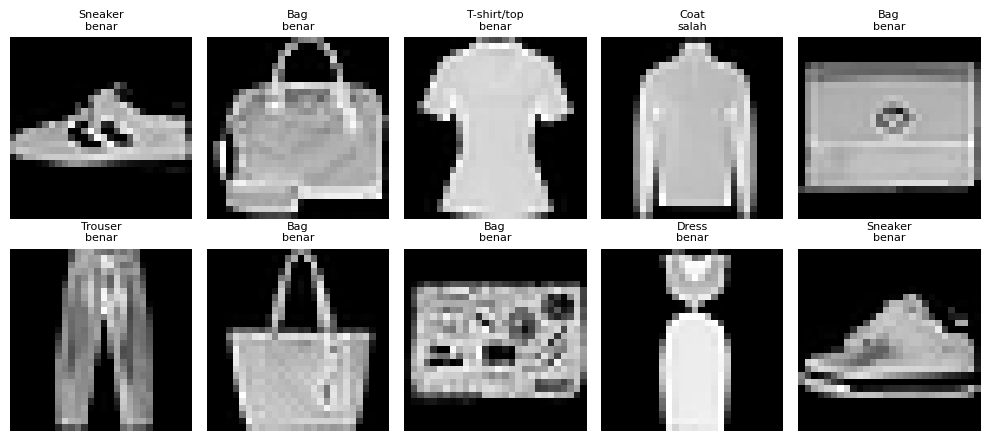

In [15]:
idxs = np.arange(10)
pred = prediksi_label(model_terbaik, X_test[idxs])
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, idx, p in zip(axes.ravel(), idxs, pred):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    benar = p == y_test[idx]
    ax.set_title(f"{NAMA_KELAS[p]}\n{'benar' if benar else 'salah'}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 14. Kesimpulan

Kesimpulan diambil dari hasil eksperimen yang sama dengan `src/proyek.py`. Jika angka berubah karena training ulang, tabel dan interpretasi perlu diperbarui mengikuti output terbaru.

In [16]:
skor = hasil[nama_terbaik]
print(
    f"Model terbaik adalah {nama_terbaik} dengan accuracy {skor['akurasi']:.4f} "
    f"dan F1 macro {skor['f1_macro']:.4f}."
)
print("Kesalahan terbesar:", tertukar[:3])


Model terbaik adalah CNN dengan accuracy 0.8737 dan F1 macro 0.8727.
Kesalahan terbesar: [(49, 'Shirt', 'T-shirt/top'), (34, 'Shirt', 'Coat'), (31, 'Pullover', 'Coat')]
